# Stratégie de Rétention Client : Prédiction du Churn Télécom
## Optimisation du Rappel (Recall) par Feature Engineering Avancé et Threshold Tuning

**Objectif Business :** L'attrition (Churn) est un défi majeur pour les opérateurs télécoms. Acquérir un nouveau client coûte entre 5 et 25 fois plus cher que d'en retenir un existant. Ce projet vise à construire un moteur de prédiction capable d'identifier les clients à risque avant qu'ils ne quittent l'entreprise.

**Contrainte Stratégique :** En marketing de rétention, rater un départ réel (Faux Négatif) a un coût d'opportunité élevé. Nous privilégions donc le **Recall (Sensibilité)** : nous acceptons quelques fausses alertes pour nous assurer de capturer au moins **75% à 80% des départs réels**.

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from google.cloud import bigquery
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Paramètres globaux et reproductibilité
RANDOM_STATE = 42
THRESHOLD = 0.38 # Seuil optimisé pour maximiser le Recall

## 1. Acquisition et Préparation des Données
Les données sont extraites directement depuis un entrepôt de données **Google Cloud BigQuery**. Cette approche garantit que notre pipeline est prêt pour le "Big Data" et facilement industrialisable. 

Nous effectuons un premier nettoyage pour supprimer les observations où les charges totales sont manquantes, car elles correspondent généralement à des clients trop récents pour une analyse de cycle de vie.

In [45]:
# Initialisation du client BigQuery
client = bigquery.Client()

# Requête d'extraction (à adapter selon votre table)
query = """
SELECT 
    * EXCEPT(customerID, TotalCharges),
    SAFE_CAST(REPLACE(TotalCharges, ' ', '0') AS FLOAT64) as TotalCharges
FROM `project-2ad74e3b-e7ac-4c49-97d.telco_churn.churn_raw`
WHERE tenure > 0 -- On élimine les anomalies du mois 0
"""
df = client.query(query).to_dataframe()

# Encodage de la cible
df['Churn'] = df['Churn'].astype(int)

# Sélection des features
features_cat = ['SeniorCitizen', 'Contract', 'InternetService', 'PaymentMethod', 'OnlineSecurity', 'TechSupport']
features_num = ['tenure', 'MonthlyCharges', 'TotalCharges']

# Création du dataset final
df_ml = pd.get_dummies(df[features_cat + features_num + ['Churn']], columns=features_cat, dtype=int)

## 2. Feature Engineering : Création de Valeur Métier
Le succès d'un modèle de Machine Learning réside souvent dans la qualité des variables d'entrée. Au lieu de nous limiter aux données brutes, nous avons conçu trois types de variables métier :

1. **HighPrice_NoCommitment** : Un "Feature Cross" capturant l'interaction entre un prix élevé et l'absence d'engagement contractuel (Month-to-month).
2. **Price Velocity & Price Diff** : Analyse de la cohérence tarifaire en comparant la facture mensuelle actuelle avec la moyenne historique (`TotalCharges / tenure`).
3. **Tenure Bins** : Segmentation temporelle pour capturer les comportements spécifiques aux nouveaux clients (phase critique de 12 mois) versus les clients fidèles.

In [46]:
def apply_feature_engineering(data):
    df_eng = data.copy()
    
    # Feature Cross : Engagement x Prix
    df_eng['HighPrice_NoCommitment'] = df_eng['Contract_Month-to-month'] * df_eng['MonthlyCharges']
    
    # Analyse des flux financiers
    df_eng['Price_Velocity'] = df_eng['TotalCharges'] / (df_eng['tenure'] + 1)
    df_eng['Price_Diff'] = df_eng['MonthlyCharges'] - df_eng['Price_Velocity']
    
    # Segmentation de l'ancienneté (Binning)
    df_eng['Tenure_Short'] = (df_eng['tenure'] <= 12).astype(int)
    df_eng['Tenure_Long'] = (df_eng['tenure'] > 36).astype(int)
    
    return df_eng

df_final = apply_feature_engineering(df_ml)

In [32]:
df_final.head(0)

,tenure,MonthlyCharges,TotalCharges,Churn,SeniorCitizen_0,SeniorCitizen_1,Contract_Month-to-month,Contract_One year,Contract_Two year,InternetService_DSL,...,OnlineSecurity_No internet service,OnlineSecurity_Yes,TechSupport_No,TechSupport_No internet service,TechSupport_Yes,HighPrice_NoCommitment,Price_Velocity,Price_Diff,Tenure_Short,Tenure_Long


## 3. Stratégie de Modélisation et Gestion de l'Imbalance
Le jeu de données présente un déséquilibre de classes (~26% de Churn). Un modèle standard aurait tendance à privilégier la précision globale au détriment de la détection du Churn.

Pour corriger cela, nous utilisons un **Random Forest** avec le paramètre `class_weight='balanced'`. Cela impose une pénalité plus forte au modèle lorsqu'il se trompe sur un client qui part, forçant ainsi l'algorithme à apprendre les caractéristiques de la classe minoritaire.

In [47]:
# Définition des features (X) et de la cible (y)
# On définit X en supprimant la colonne Churn
X = df_final.drop(['Churn'], axis=1, errors='ignore')
# Juste avant le split X, y

# On définit y avec uniquement la colonne Churn
y = df_final['Churn']

# Découpage 60% Train / 20% Validation / 20% Test
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=RANDOM_STATE)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=RANDOM_STATE)

# Entraînement du modèle
model = RandomForestClassifier(
    n_estimators=100, 
    max_depth=10, 
    class_weight='balanced', 
    random_state=RANDOM_STATE
)
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## 4. Évaluation et Threshold Tuning (Ajustement du Seuil)
Par défaut, un classifieur prédit une résiliation si la probabilité dépasse 50%. Cependant, pour répondre à notre objectif business de **Recall élevé**, nous avons analysé la courbe Precision-Recall pour identifier un point d'inflexion optimal.

Nous avons ajusté le seuil de décision à **0.38**. Ce réglage permet de maximiser la détection des départs tout en conservant une précision supérieure à 50%, assurant ainsi la rentabilité des futures campagnes marketing.

Rapport de Classification au Seuil 0.38 :
              precision    recall  f1-score   support

           0       0.91      0.72      0.80      1036
           1       0.50      0.79      0.61       371

    accuracy                           0.74      1407
   macro avg       0.70      0.75      0.71      1407
weighted avg       0.80      0.74      0.75      1407



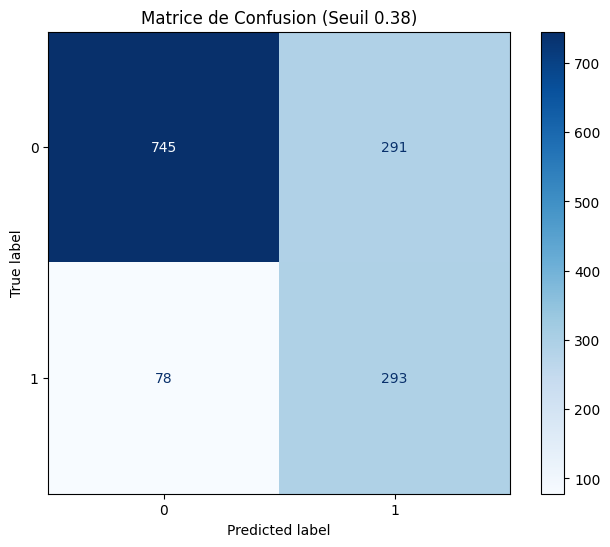

In [48]:
# Calcul des probabilités sur le jeu de test
y_probs = model.predict_proba(X_test)[:, 1]
y_pred_custom = (y_probs >= THRESHOLD).astype(int)

print(f"Rapport de Classification au Seuil {THRESHOLD} :")
print(classification_report(y_test, y_pred_custom))

# Visualisation de la matrice de confusion
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_custom, cmap='Blues', ax=ax)
plt.title(f"Matrice de Confusion (Seuil {THRESHOLD})")
plt.show()

## 5. Interprétabilité : Pourquoi les clients partent-ils ?
L'un des avantages du Random Forest est sa capacité à classer l'importance des variables. Cette étape est cruciale pour le département marketing afin de comprendre les leviers sur lesquels agir (ex: baisser le prix pour les contrats sans engagement).

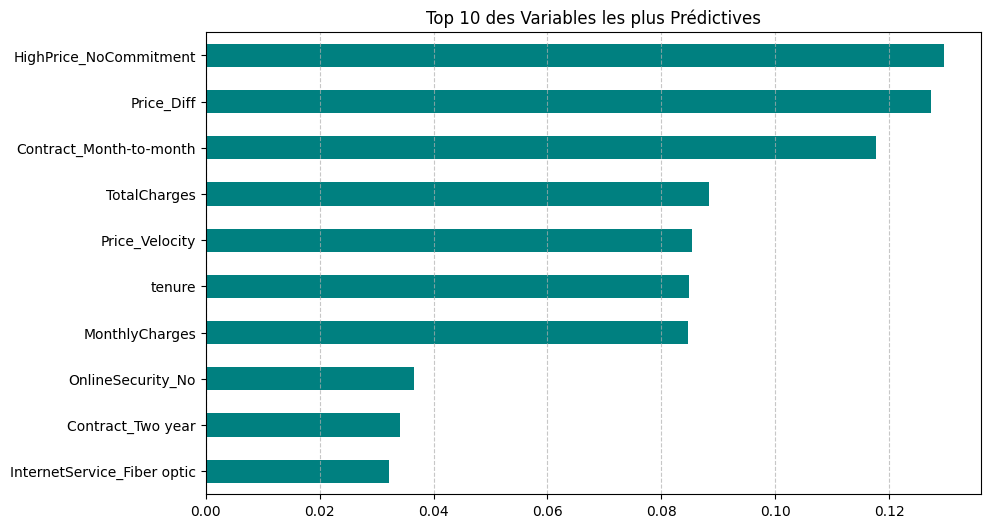

In [49]:
importances = pd.Series(model.feature_importances_, index=X.columns)
plt.figure(figsize=(10,6))
importances.nlargest(10).plot(kind='barh', color='#008080')
plt.title("Top 10 des Variables les plus Prédictives")
plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

## 6. Conclusion et Mise en Production (MLOps)
Le modèle final est exporté sous format compressé `.pkl`. Il intègre non seulement les poids de l'algorithme, mais aussi la liste des colonnes requises et le seuil de décision optimisé. 

**Prochaine étape :** Déploiement du modèle sous forme d'application interactive avec **Streamlit** et hébergement sur **Google Cloud Run** pour permettre aux agents du service client de tester des scénarios en temps réel.

In [51]:
# Sauvegarde du package final
model_package = {
    'model': model,
    'features': X.columns.tolist(),
    'threshold': THRESHOLD
}
joblib.dump(model_package, 'telco_churn_model_final.pkl')
print("✅ Modèle sauvegardé avec succès pour le déploiement.")

✅ Modèle sauvegardé avec succès pour le déploiement.
